<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 20px; border-radius: 10px; color: white; text-align: center; width: auto; max-width: 100%;">
<h1 style="color: white;"> ПРАКТИЧЕСКАЯ РАБОТА № 2</h1>
<h2 style="color: white;">Формирование портфеля ИТ-проектов на основе ROI и рисков</h2>
</div>

---

## Цель работы

> Освоить методы количественной оценки и приоритизации ИТ-проектов для формирования оптимального инвестиционного портфеля с учётом доходности, рисков и стратегического соответствия.

---

## Описание данных

Набор данных: **`it_portfolio_projects.csv`**

| Поле | Описание | Ед. изм. / Шкала |
|------|----------|------------------|
| `project_name` | Название проекта | Текст |
| `investment` | Требуемые капитальные вложения | Руб. |
| `expected_revenue` | Ожидаемая выручка или экономия за 3 года | Руб. |
| `risk_score` | Оценка риска проекта | 1–10 (10 — макс. риск) |
| `alignment_score` | Степень соответствия стратегии компании | 1–5 (5 — макс. соотв.) |
| `duration_months` | Плановая длительность реализации | Мес. |

---

##  Методология оценки проектов

Для ранжирования и отбора проектов в портфель используются следующие расчетные показатели:

### 1. Рентабельность инвестиций (ROI)
Показатель эффективности вложений за 3 года.


### 2. Индекс стратегической ценности (Value Index)
Комплексный показатель, учитывающий не только доходность, но и риски с длительностью. Позволяет найти баланс «риск / доходность / стратегия».


*Примечание: Делитель `√duration_months` используется для поощрения более быстрых проектов (принцип «время — деньги»).*

---

##  Задачи практической работы

1. **Загрузка и предобработка данных**: Проверить типы данных, наличие пропусков, рассчитать базовые показатели (ROI).
2. **Расчет Value Index**: Вычислить метрику приоритизации для каждого проекта.
3. **Построение пузырьковой диаграммы (Bubble Chart)**:
   - Ось X: `risk_score`
   - Ось Y: `ROI`
   - Размер пузырька: `investment` (бюджет проекта)
   - Цвет: `alignment_score`
4. **Формирование портфеля**:
   - Отобрать ТОП-5 проектов по значению `Value_Index`.
   - Проверить ограничение по общему бюджету портфеля (например, лимит = 15 000 000 руб.).
   - При превышении лимита исключить наименее приоритетный проект и добавить следующий из рейтинга.
5. **Выводы**: Описать итоговый портфель и объяснить, почему были выбраны именно эти проекты с точки зрения стратегии и управления рисками.

---

##  Ожидаемый результат

Результатом работы является:
- **Таблица ранжированных проектов** с рассчитанным `Value_Index`.
- **Визуализация** матрицы «Риск / Доходность».
- **Сформированный портфель проектов** в рамках заданного бюджетного ограничения.
- **Аналитическая записка** с обоснованием выбора.

---



## 1. Импорт библиотек

На данном этапе загружаются все необходимые библиотеки для анализа и формирования портфеля ИТ-проектов.

### Работа с данными
- **`pandas`** — загрузка, обработка и анализ табличных данных (CSV-файла)
- **`numpy`** — выполнение математических операций и работа с массивами

### Визуализация
- **`matplotlib.pyplot`** — построение графиков (scatter plot для анализа ROI и риска)

### Оптимизация и алгоритмы
- **`scipy.optimize`** *(опционально)* — решение задачи оптимизации (например, задача «рюкзака» для выбора проектов)

### Настройки окружения
- **`warnings.filterwarnings('ignore')`** — отключение предупреждений для более чистого вывода

### Примечание
Основной упор в работе сделан на:
- анализ эффективности проектов через показатель ROI;
- нормализацию данных;
- построение интегрального рейтинга;
- применение жадного алгоритма для формирования инвестиционного портфеля.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

## 2. Загрузка данных

Выполняется загрузка исходного датасета с информацией о завершенных ИТ-проектах компании.

```python
data1_df = pd.read_csv("it_portfolio_projects.csv")



In [39]:
data1_df = pd.read_csv("it_portfolio_projects.csv")

#### Первичный просмотр данных

Смотрим первый 10 строк 

```python
data1_df.head(10)

In [40]:
data1_df.head(10)

,project_name,investment,expected_revenue,risk_score,alignment_score,duration_months
0,Smart Platform 1,2250496.45,3012879.30,2,1,27
1,Smart Suite 2,192169.77,193347.68,2,5,25
2,Digital Framework 3,2176456.88,5099253.34,10,2,20
3,Data Platform 4,2300541.36,2648499.39,4,3,14
4,Cloud Framework 5,2875917.91,4430374.54,5,4,9
5,NextGen Engine 6,1850805.49,4767086.76,10,5,9
6,Enterprise System 7,1700917.83,4464382.47,9,5,12
7,Smart Platform 8,2017663.62,5045673.01,7,2,33
8,Smart Suite 9,906123.45,1992117.64,9,2,17
9,NextGen Framework 10,2043508.01,4789992.35,7,5,26


#### Первичная проверка данных

```python
# Размер датасета
print("Размер датасета:", data1_df.shape)

# Информация о столбцах и типах данных
data1_df.info()

# Проверка пропусков
print(data1_df.isnull().sum())

# Статистическое описание
data1_df.describe()

In [41]:
print("Размер датасета:", data1_df.shape)
print("\n")
data1_df.info()
print("\n")
print(data1_df.isnull().sum())
print("\n")
data1_df.describe()

Размер датасета: (200, 6)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   project_name      200 non-null    object 
 1   investment        200 non-null    float64
 2   expected_revenue  200 non-null    float64
 3   risk_score        200 non-null    int64  
 4   alignment_score   200 non-null    int64  
 5   duration_months   200 non-null    int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB


project_name        0
investment          0
expected_revenue    0
risk_score          0
alignment_score     0
duration_months     0
dtype: int64




,investment,expected_revenue,risk_score,alignment_score,duration_months
count,2.000000e+02,2.000000e+02,200.000000,200.000000,200.000000
mean,1.576844e+06,2.946381e+06,6.350000,3.015000,20.735000
std,8.596223e+05,1.882490e+06,2.598318,1.398051,8.714614
min,1.234841e+05,1.933477e+05,1.000000,1.000000,6.000000
25%,8.031156e+05,1.376470e+06,5.000000,2.000000,13.000000
50%,1.522153e+06,2.621020e+06,7.000000,3.000000,21.000000
75%,2.331397e+06,4.181290e+06,8.000000,4.000000,28.000000
max,2.995902e+06,7.981252e+06,10.000000,5.000000,36.000000


## 1. Расчёт ROI для каждого проекта

Для каждого проекта рассчитывается показатель возврата инвестиций (ROI):

Этот показатель позволяет оценить прибыльность проекта.

In [42]:
data1_df['ROI'] = ((data1_df['expected_revenue'] - data1_df['investment']) / data1_df['investment']) * 100

## 2. Нормализация показателей риска и соответствия стратегии

Показатели `risk_score` и `alignment_score` приводятся к диапазону [0, 1] с использованием метода Min-Max Scaling:

Это необходимо для корректного сравнения показателей разной шкалы.


In [43]:
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

data1_df['risk_score_norm'] = min_max_scale(data1_df['risk_score'])
data1_df['alignment_score_norm'] = min_max_scale(data1_df['alignment_score'])

## 3. Расчёт интегрального показателя (score)

Для оценки приоритетности проектов рассчитывается интегральный рейтинг:

Если нормализованный риск равен 0, значение `score` принимается равным 0 (во избежание деления на ноль).


In [44]:
def calculate_score(row):
    if row['risk_score_norm'] == 0:
        return 0
    return (row['ROI'] * row['alignment_score_norm']) / row['risk_score_norm']

data1_df['score'] = data1_df.apply(calculate_score, axis=1)

## 4. Сортировка проектов по приоритету

Проекты сортируются по убыванию значения `score`, что позволяет определить наиболее привлекательные для инвестирования проекты.


In [45]:
df_sorted = data1_df.sort_values(by='score', ascending=False).reset_index(drop=True)

## 5. Формирование портфеля 

Реализуется жадный алгоритм:
- проекты последовательно выбираются по убыванию `score`;
- добавление проекта происходит, если общий бюджет не превышает 5_000_000 руб.

Цель — максимизация суммарного рейтинга при ограниченном бюджете.


In [46]:
budget_limit = 5_000_000
selected_projects = []
total_investment = 0

for _, row in df_sorted.iterrows():
    if total_investment + row['investment'] <= budget_limit:
        selected_projects.append(row)
        total_investment += row['investment']

selected_df = pd.DataFrame(selected_projects)

## 6. Вывод таблицы выбранных проектов

Отобранные проекты выводятся в виде таблицы с ключевыми показателями:
- название проекта;
- инвестиции;
- ROI;
- интегральный рейтинг (`score`).


Строится точечный график распределения проектов:
- ось X — `risk_score` (риск);
- ось Y — `ROI` (доходность);
- выбранные проекты выделяются отдельным цветом.

График позволяет наглядно оценить баланс между риском и доходностью.

          project_name  investment         ROI       score
0        AI Engine 163   145765.14   38.380857  259.070785
1   Enterprise Hub 143   123484.10  170.314826  255.472239
2   Cloud Platform 161   904097.05  196.486190  252.625102
3            AI Hub 29  2040035.56   27.132098  244.188879
4      Data Engine 191   742558.97  151.405931  227.108896
14      AI Gateway 152   172571.48  174.531672  196.348131
15        AI System 23   348395.01   86.917901  195.565277
17       AI Engine 187   309018.94  169.588159  190.786678
99  NextGen Gateway 22   156482.55  184.401698   51.862978

Общий бюджет: 4942408.800000001
Количество проектов: 9


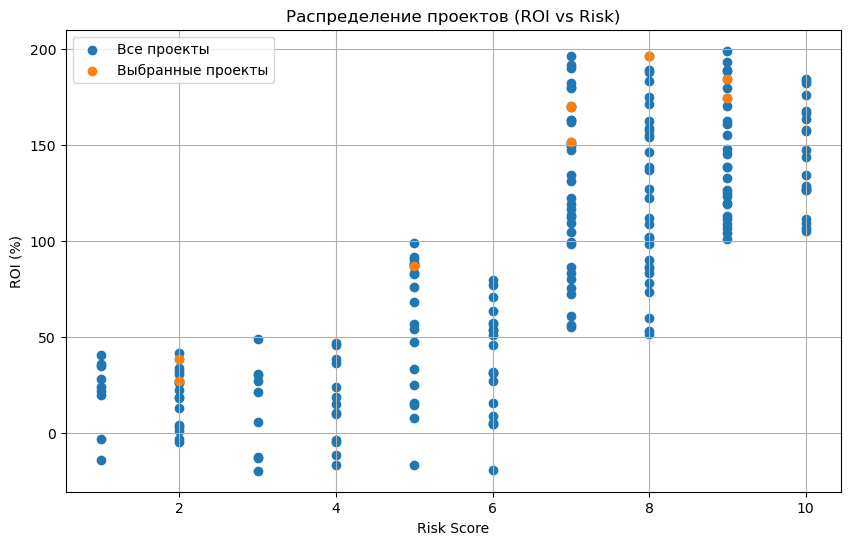

In [47]:

print(selected_df[['project_name', 'investment', 'ROI', 'score']])

print("\nОбщий бюджет:", total_investment)
print("Количество проектов:", len(selected_df))

plt.figure(figsize=(10, 6))

plt.scatter(data1_df['risk_score'], data1_df['ROI'], label='Все проекты')

plt.scatter(selected_df['risk_score'], selected_df['ROI'], 
            label='Выбранные проекты', marker='o')

plt.xlabel('Risk Score')
plt.ylabel('ROI (%)')
plt.title('Распределение проектов (ROI vs Risk)')
plt.legend()
plt.grid()

plt.show()

In [2]:
import sys
sys.executable

'/opt/anaconda3/envs/ifrs9/bin/python'

In [4]:
%pip list

Package                   Version
------------------------- ------------
anyio                     4.12.1
appnope                   0.1.4
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
asttokens                 3.0.1
async-lru                 2.0.5
attrs                     25.4.0
babel                     2.17.0
beautifulsoup4            4.14.3
bleach                    6.3.0
Bottleneck                1.4.2
brotlicffi                1.2.0.0
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.4
colablink                 1.0.0
comm                      0.2.3
contourpy                 1.3.1
cryptography              46.0.5
cycler                    0.12.1
Cython                    3.2.4
debugpy                   1.8.16
decorator                 5.2.1
defusedxml                0.7.1
exceptiongroup            1.3.0
executing                 2.2.1
fastjsonschema            2.21.2
fonttools                 4.61.0
google-api-cor